## Importacion de librerias

Librerias necesarias para cargar y visualizar los resultados.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## Carga de resultados

Lectura del archivo CSV con las metricas de evaluacion.

In [5]:
results_file = 'model_results.csv'

if not Path(results_file).exists():
    print(f"Error: {results_file} no encontrado. Ejecuta eval.ipynb primero.")
else:
    df_results = pd.read_csv(results_file)
    print("Resultados cargados correctamente\n")
    print(df_results.to_string(index=False))

Resultados cargados correctamente

  Model  mAP50  mAP50-95  Precision  Recall  Accuracy
yolov8n 0.6075    0.5938     0.5093  0.6521    0.5067
yolov8s 0.6504    0.6358     0.5498  0.6345    0.6329
yolov8m 0.6639    0.6608     0.5631  0.6472    0.5823


## Tabla comparativa

Tabla formateada con todas las metricas de rendimiento.

In [6]:
print("\n" + "="*80)
print("COMPARACION DE RENDIMIENTO DE MODELOS YOLO")
print("="*80 + "\n")

pd.set_option('display.float_format', lambda x: f'{x:.4f}')
print(df_results.to_string(index=False))
print("\n" + "="*80)

print("\nMejor modelo por metrica:")
for col in ['mAP50', 'mAP50-95', 'Precision', 'Recall', 'Accuracy']:
    best_idx = df_results[col].idxmax()
    best_model = df_results.loc[best_idx, 'Model']
    best_value = df_results.loc[best_idx, col]
    print(f"  {col:12s}: {best_model} ({best_value:.4f})")


COMPARACION DE RENDIMIENTO DE MODELOS YOLO

  Model  mAP50  mAP50-95  Precision  Recall  Accuracy
yolov8n 0.6075    0.5938     0.5093  0.6521    0.5067
yolov8s 0.6504    0.6358     0.5498  0.6345    0.6329
yolov8m 0.6639    0.6608     0.5631  0.6472    0.5823


Mejor modelo por metrica:
  mAP50       : yolov8m (0.6639)
  mAP50-95    : yolov8m (0.6608)
  Precision   : yolov8m (0.5631)
  Recall      : yolov8n (0.6521)
  Accuracy    : yolov8s (0.6329)


## Visualizacion de metricas individuales

Graficas de barras para cada metrica de evaluacion.

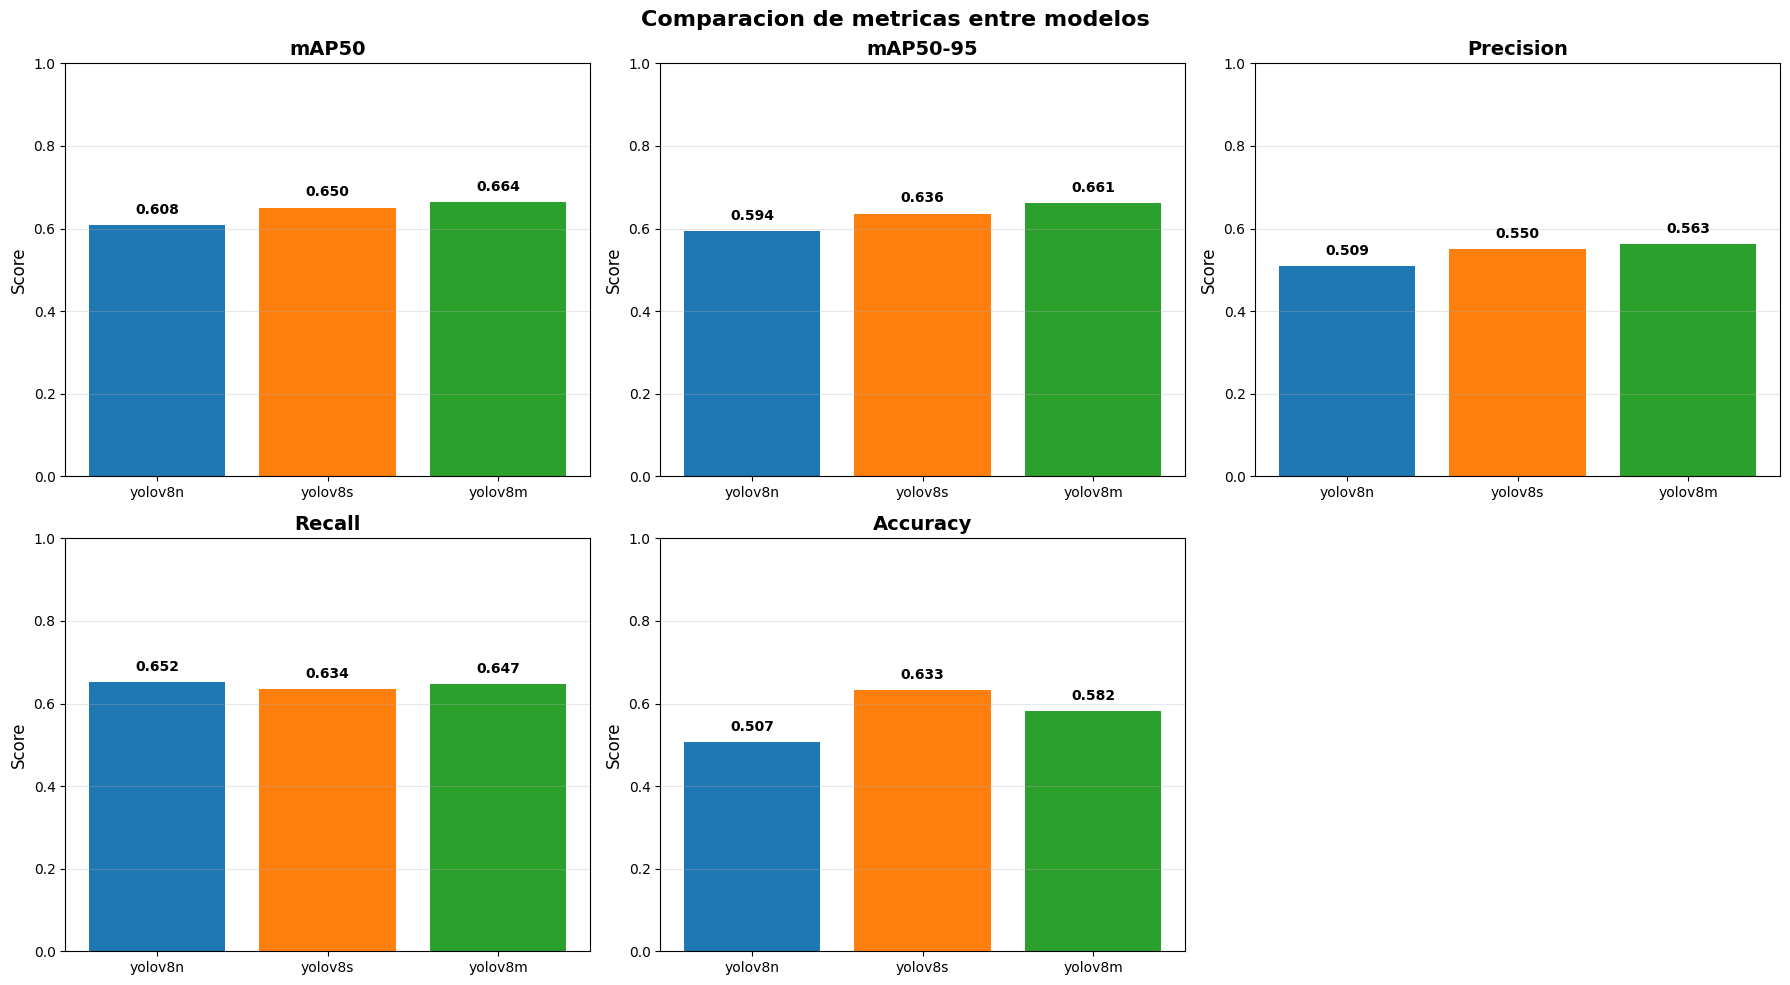

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Comparacion de metricas entre modelos', fontsize=16, fontweight='bold')

metrics_to_plot = ['mAP50', 'mAP50-95', 'Precision', 'Recall', 'Accuracy']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, metric in enumerate(metrics_to_plot):
    row = idx // 3
    col = idx % 3
    
    axes[row, col].bar(df_results['Model'], df_results[metric], color=colors)
    axes[row, col].set_title(metric, fontsize=14, fontweight='bold')
    axes[row, col].set_ylabel('Score', fontsize=12)
    axes[row, col].set_ylim(0, 1)
    axes[row, col].grid(True, alpha=0.3, axis='y')
    
    for i, v in enumerate(df_results[metric]):
        axes[row, col].text(i, v + 0.02, f'{v:.3f}', 
                           ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Grafica de radar

Comparacion multi-dimensional de las metricas principales.

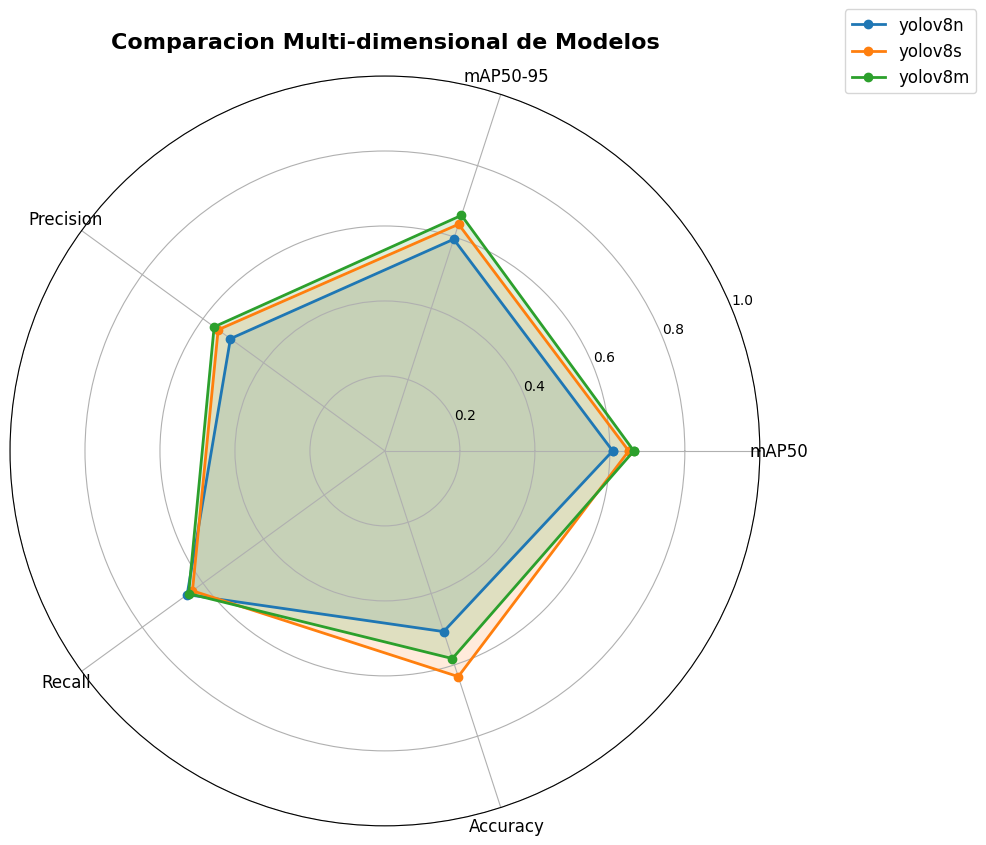

In [8]:
from math import pi

categories = ['mAP50', 'mAP50-95', 'Precision', 'Recall', 'Accuracy']
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

colors_radar = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, row in df_results.iterrows():
    values = row[categories].values.flatten().tolist()
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=colors_radar[idx])
    ax.fill(angles, values, alpha=0.15, color=colors_radar[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=10)
ax.grid(True)

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)
plt.title('Comparacion Multi-dimensional de Modelos', size=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('radar_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Grafica de lineas

Tendencia de mejora con el aumento de complejidad del modelo.

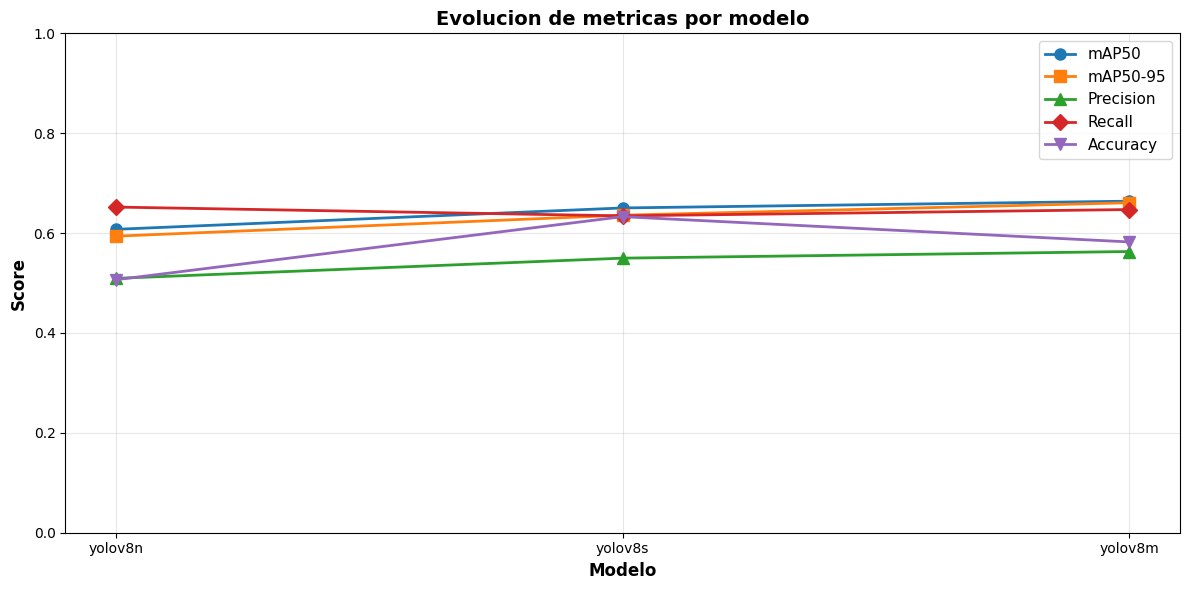

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

metrics_line = ['mAP50', 'mAP50-95', 'Precision', 'Recall', 'Accuracy']
markers = ['o', 's', '^', 'D', 'v']

for idx, metric in enumerate(metrics_line):
    ax.plot(df_results['Model'], df_results[metric], 
            marker=markers[idx], linewidth=2, markersize=8, label=metric)

ax.set_xlabel('Modelo', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Evolucion de metricas por modelo', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='best')

plt.tight_layout()
plt.savefig('line_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Heatmap de metricas

Mapa de calor para visualizar todas las metricas simultaneamente.

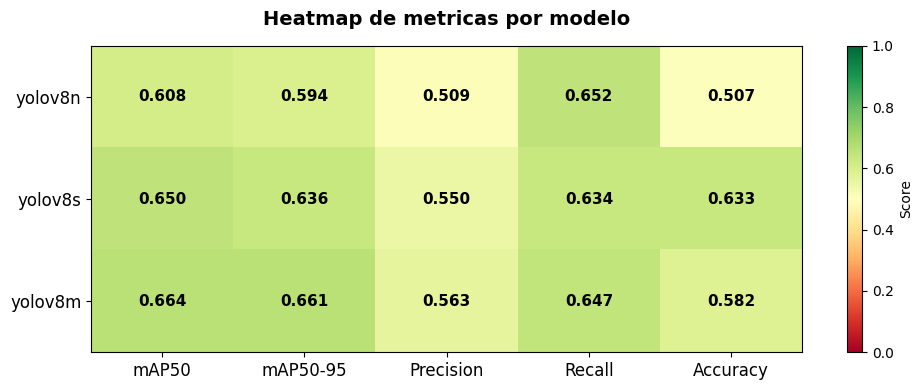

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))

metrics_heatmap = df_results[['mAP50', 'mAP50-95', 'Precision', 'Recall', 'Accuracy']].values

im = ax.imshow(metrics_heatmap, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(np.arange(len(categories)))
ax.set_yticks(np.arange(len(df_results)))
ax.set_xticklabels(categories, fontsize=12)
ax.set_yticklabels(df_results['Model'], fontsize=12)

for i in range(len(df_results)):
    for j in range(len(categories)):
        text = ax.text(j, i, f'{metrics_heatmap[i, j]:.3f}',
                      ha="center", va="center", color="black", fontsize=11, fontweight='bold')

ax.set_title('Heatmap de metricas por modelo', fontsize=14, fontweight='bold', pad=15)
fig.colorbar(im, ax=ax, label='Score')

plt.tight_layout()
plt.savefig('heatmap_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Analisis de diferencias

Diferencias relativas entre modelos consecutivos.

In [11]:
print("\n" + "="*80)
print("ANALISIS DE MEJORA ENTRE MODELOS")
print("="*80 + "\n")

for i in range(1, len(df_results)):
    model_prev = df_results.loc[i-1, 'Model']
    model_curr = df_results.loc[i, 'Model']
    
    print(f"Mejora de {model_prev} -> {model_curr}:\n")
    
    for metric in ['mAP50', 'mAP50-95', 'Precision', 'Recall', 'Accuracy']:
        val_prev = df_results.loc[i-1, metric]
        val_curr = df_results.loc[i, metric]
        diff = val_curr - val_prev
        pct = (diff / val_prev * 100) if val_prev > 0 else 0
        
        sign = "+" if diff >= 0 else ""
        print(f"  {metric:12s}: {sign}{diff:+.4f} ({sign}{pct:+.2f}%)")
    
    print("\n")


ANALISIS DE MEJORA ENTRE MODELOS

Mejora de yolov8n -> yolov8s:

  mAP50       : ++0.0428 (++7.05%)
  mAP50-95    : ++0.0420 (++7.08%)
  Precision   : ++0.0405 (++7.95%)
  Recall      : -0.0176 (-2.70%)
  Accuracy    : ++0.1262 (++24.92%)


Mejora de yolov8s -> yolov8m:

  mAP50       : ++0.0135 (++2.08%)
  mAP50-95    : ++0.0249 (++3.92%)
  Precision   : ++0.0132 (++2.41%)
  Recall      : ++0.0127 (++2.00%)
  Accuracy    : -0.0506 (-8.00%)




## Resumen estadistico

Estadisticas descriptivas de las metricas.

In [12]:
print("\n" + "="*80)
print("ESTADISTICAS DESCRIPTIVAS")
print("="*80 + "\n")

stats = df_results[['mAP50', 'mAP50-95', 'Precision', 'Recall', 'Accuracy']].describe()
print(stats)

print("\n\nRango de variacion por metrica:")
for metric in ['mAP50', 'mAP50-95', 'Precision', 'Recall', 'Accuracy']:
    min_val = df_results[metric].min()
    max_val = df_results[metric].max()
    range_val = max_val - min_val
    print(f"  {metric:12s}: [{min_val:.4f}, {max_val:.4f}] (rango: {range_val:.4f})")


ESTADISTICAS DESCRIPTIVAS

       mAP50  mAP50-95  Precision  Recall  Accuracy
count 3.0000    3.0000     3.0000  3.0000    3.0000
mean  0.6406    0.6301     0.5407  0.6446    0.5740
std   0.0294    0.0338     0.0280  0.0091    0.0635
min   0.6075    0.5938     0.5093  0.6345    0.5067
25%   0.6289    0.6148     0.5296  0.6408    0.5445
50%   0.6504    0.6358     0.5498  0.6472    0.5823
75%   0.6571    0.6483     0.5564  0.6496    0.6076
max   0.6639    0.6608     0.5631  0.6521    0.6329


Rango de variacion por metrica:
  mAP50       : [0.6075, 0.6639] (rango: 0.0564)
  mAP50-95    : [0.5938, 0.6608] (rango: 0.0670)
  Precision   : [0.5093, 0.5631] (rango: 0.0537)
  Recall      : [0.6345, 0.6521] (rango: 0.0176)
  Accuracy    : [0.5067, 0.6329] (rango: 0.1262)
